In [1]:
import numpy as np
from numpy.random import default_rng
from numpy.fft import rfft, irfft, fft, ifft
from scipy.optimize import bisect, minimize, minimize_scalar
import scipy.signal as sig
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset, zoomed_inset_axes

import scienceplots

plt.style.use('science')

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

from pycbc.filter import resample_to_delta_t, highpass
from pycbc.psd import interpolate, inverse_spectrum_truncation
from pycbc.waveform import get_fd_waveform
from pycbc.waveform.utils import taper_timeseries
from pycbc.filter import sigma, sigmasq, matched_filter, match, overlap_cplx
from pycbc.types import FrequencySeries, TimeSeries
from pycbc.psd.analytical import aLIGO175MpcT1800545 as psd_function

PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


In [2]:
import sys
sys.path.insert(1, '../detectability')

import resonance
from resonance import System, Filter, phase_diff_t_shift, phase_shift 

In [3]:
import os

In [4]:
tlen = 512
srate = 4096
flen = 1+tlen*srate//2
df = 1./tlen

f_low = 15
f_high = 1024
sl = slice(int(f_low/df), int(f_high/df))

freqs = (df*np.arange(flen))[sl]

#t_shift = 0.005


In [5]:
#check functions for default parameters

m1 = 1.4 # M_sun
m2 = 1.4 # M_sun

f_low, f_high, tlen, srate, dL, approximant, detector = [15, 1024, 512, 4096, 100, 'IMRPhenomD','aLIGO/Asharp_strain']#'IMRPhenomD', 'aLIGO/Asharp_strain']

binary = System(m1, m2)

filt = Filter(f_low, f_high, tlen, srate, dL, approximant, detector) #f_low, f_high, tlen, srate, dL, approximant, detector

/home/alberto/ns-resonance/jupyter-env/lib/python3.12/site-packages/pycbc/types/array.py:390: RuntimeWarning: divide by zero encountered in divide
  return self._data.__rtruediv__(other)


In [6]:
eps = 1 #7.,1.

dt = 1e-3*eps
fres = 100


shift = 128 #int(t_shift * filt.srate)


$snr=\frac{\langle h,s\rangle}{\sqrt{\langle h,h\rangle}}$

/tmp/ipykernel_8851/686181300.py:33: UserWarning: Using the axes or figure transform requires a bounding box in the respective coordinates. Using bbox_to_anchor=(0, 0, 1, 1) now.
  axins = inset_axes(ax, width="30%", height="70%", loc='upper right', bbox_transform=ax.transAxes, borderpad=0.5)
/tmp/ipykernel_8851/686181300.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_8851/686181300.py:33: UserWarning: Using the axes or figure transform requires a bounding box in the respective coordinates. Using bbox_to_anchor=(0, 0, 1, 1) now.
  axins = inset_axes(ax, width="30%", height="70%", loc='upper right', bbox_transform=ax.transAxes, borderpad=0.5)
/tmp/ipykernel_8851/686181300.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_8851/686181300.py:33: UserWarning: Using the axes or fi

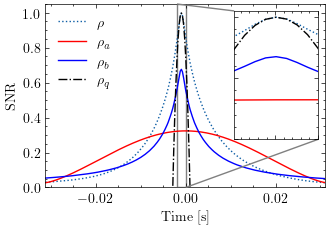

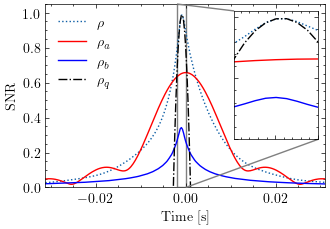

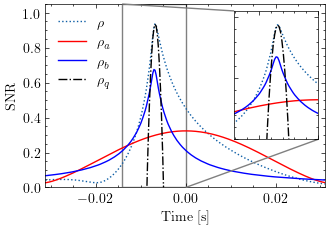

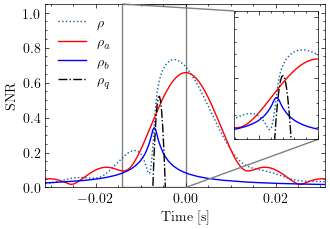

In [7]:
for dt in [1e-3,7e-3]:
    for fres in [50,100]:
        dPsi = phase_diff_t_shift(dt, fres, filt.freqs)

        i7, i4, i1 = filt.J()
        idY7, idY4, idYsq7 = filt.J_dPsi(dPsi)
        
        tx, rho_abs, rhoa_abs, rhob_abs = filt.rho_abs_roll_split(dt,fres, shift)
        rhoq = 1-(idYsq7+2*idY4*tx+i1*tx**2-(idY7+i4*tx)**2)/2 
        
        
        fig, ax = plt.subplots(figsize=(3.5, 2.5))
        #plt.figure(figsize=(3.5, 2.5), constrained_layout=True)
        
        ax.plot(tx, rho_abs, ls=':', label = r'$\rho$')
        ax.plot(tx, rhoa_abs, c='r', label = r'$\rho_a$')
        ax.plot(tx, rhob_abs, c='b', label = r'$\rho_b$')
        
        ax.plot(tx, rhoq, ls='-.', c='k', label = r'$\rho_q$')
        
        
        ax.set_xlabel('Time [s]')
        ax.set_ylabel('SNR')
        
        ax.set_xlim(tx[0],tx[-1])
        ax.set_ylim(0.,1.05) #50,150 Hz
        #ax.set_title(f'Time shift = {dt} s. Resonant frequency = {fres} Hz',fontsize=10)
        ax.legend(loc='upper left')
        
        # Create a zoomed inset
        # Option 1: specify zoom factor
        #axins = zoomed_inset_axes(ax, zoom=3, loc='upper left')  # zoom = 3x, upper-right corner
        axins = inset_axes(ax, width="30%", height="70%", loc='upper right', bbox_transform=ax.transAxes, borderpad=0.5)
        
        axins.plot(tx, rho_abs, ls=':')
        axins.plot(tx, rhoa_abs, c='r')
        axins.plot(tx, rhob_abs, c='b')
        
        axins.plot(tx, rhoq, ls='-.', c='k')
        
        # Set the limits of the zoomed region
        x1, x2, y1, y2 = tx[np.argmax(rhob_abs)]*2,0, 0., 1.05
        axins.set_xlim(x1, x2)
        axins.set_ylim(y1, y2)
        
        # Remove tick labels for clarity
        axins.set_xticklabels([])
        axins.set_yticklabels([])
        
        # Optionally, draw lines connecting the zoomed area
        mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")
        
        plt.tight_layout()
        
        plt.savefig(os.path.join('figures/0_basis', f'rho_abs_roll_split_{dt}s_{fres}Hz.png'), bbox_inches='tight', dpi=300)
        
        #plt.show()

(0.0, 1.05)

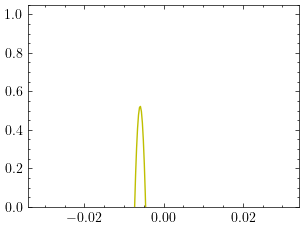

In [8]:
plt.plot(tx, rhoq, c='y', label = r'$\rho_q(t)$')
plt.ylim(0.,1.05) #50,150 Hz



In [ ]:
eps